# COMP 3610 Assignemnt 3
## 816039987

# Part 1  
## Task 1.1 Spark Environment Setup & Data Loading

#### Download the NYC Taxi Parquet data programmatically using urllib and os.

In [5]:
import urllib.request
import os

#Creates the data directory if it does not already exist
os.makedirs('data/raw', exist_ok=True)
url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet'
output = 'data/raw/yellow_tripdata_2024-01.parquet'

#Checks if the file is already downloaded to avoid redundant network requests
if not os.path.exists(output):
    print('Downloading NYC Taxi data...')
    urllib.request.urlretrieve(url, output)
    print(f'Downloaded: {os.path.getsize(output) / 1e6:.1f} MB')
else:
    print(f'File already exists: {os.path.getsize(output) / 1e6:.1f} MB')

Downloaded: 50.0 MB


#### Create a SparkSession configured with a named app, specific memory, and adaptive query execution.

In [6]:
from pyspark.sql import SparkSession

#local[*] tells Spark to use all available CPU cores for the local cluster
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('COMP3610_Assignment3') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .config('spark.driver.memory', '4g') \
    .getOrCreate()

#Verify the Session
print(f'Spark version: {spark.version}')
print(f'App name: {spark.sparkContext.appName}')
print(f'Master: {spark.sparkContext.master}')
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}')

Spark version: 4.0.2
App name: COMP3610_Assignment3
Master: local[*]
Default parallelism: 2


#### Load the data, print the schema, output counts, and compare load times with Pandas.

In [7]:
import time
import pandas as pd

#Time Spark read (lazy evaluation - Spark only reads the Parquet metadata here, not the data)
start_spark = time.time()
df_spark = spark.read.parquet(output)
spark_read_time = time.time() - start_spark

#Time Pandas full read (eager execution - Pandas loads the entire file into memory immediately)
start_pandas = time.time()
df_pandas = pd.read_parquet(output)
pandas_read_time = time.time() - start_pandas

df_spark.printSchema()

#df.rdd.getNumPartitions() gets the number of partitions the DataFrame is split into across the cluster
print(f"Total Rows: {df_spark.count():,}")
print(f"Partitions: {df_spark.rdd.getNumPartitions()}")
print(f"Spark Load Time (metadata only): {spark_read_time:.3f}s")
print(f"Pandas Load Time (full memory load): {pandas_read_time:.3f}s")

#Clean up Pandas DataFrame to free up your machine's memory
del df_pandas

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

Total Rows: 2,964,624
Partitions: 2
Spark Load Time (metadata only): 4.888s
Pandas Load Time (full memory load): 1.082s


#### Interpretation:
As seen in the output, Pandas loaded the entire 2.96 million-row dataset into memory significantly faster (1.082s) than Spark took just to read the file's metadata (4.888s). This performance difference highlights the architectural contrast between Pandas' highly optimized, eager in-memory execution and Spark's distributed framework. Although Spark utilizes lazy evaluation, meaning the 4.888s reflects the time taken to infer the schema and partition info rather than loading the actual data, this duration primarily captures the "cold start" overhead of initializing the JVM and Spark Session. For datasets of this size that fit comfortably within local RAM, Pandas avoids this cluster initialization overhead, making it faster for single-node loads, whereas Spark's true advantage emerges when scaling to massive datasets that would otherwise cause Pandas to crash.

## Task 1.2 Data Cleaning & Feature Engineering in Spark


In [8]:
#import spark sql functions
from pyspark.sql import functions as F

#Store the initial row count to track dropped rows throughout the cleaning process
initial_count = df_spark.count()
print(f"Initial row count: {initial_count:,}")

#Drop rows containing null values in the critical columns
critical_cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'fare_amount', 'trip_distance']
trips_no_nulls = df_spark.dropna(subset=critical_cols)

#Calculate and report rows removed during the null-dropping step
count_after_nulls = trips_no_nulls.count()
print(f"Rows removed due to nulls: {initial_count - count_after_nulls:,}")

#Filter out invalid trips by chaining conditions with the bitwise AND operator
#Compare timestamps directly to ensure dropoff happens after pickup, preventing negative durations
trips_clean = trips_no_nulls.filter(
    (F.col('trip_distance') > 0) &
    (F.col('fare_amount') > 0) &
    (F.col('fare_amount') <= 500) &
    (F.col('tpep_dropoff_datetime') > F.col('tpep_pickup_datetime'))
)

#Calculate and report rows removed by the invalid data filters
count_after_filter = trips_clean.count()
print(f"Rows removed due to invalid data constraints: {count_after_nulls - count_after_filter:,}")

#Calculate trip duration in minutes by converting timestamps to unix epoch seconds, subtracting, and dividing by 60
trips_enriched = trips_clean.withColumn(
    'trip_duration_minutes',
    (F.unix_timestamp('tpep_dropoff_datetime') - F.unix_timestamp('tpep_pickup_datetime')) / 60
)

#Calculate speed in mph. Use F.when() to safely handle division by zero in case any remaining trips have a duration of 0
trips_enriched = trips_enriched.withColumn(
    'trip_speed_mph',
    F.when(F.col('trip_duration_minutes') > 0, F.col('trip_distance') / (F.col('trip_duration_minutes') / 60)).otherwise(0)
)

#Extract the hour of the day (0-23) and the day of the week (1=Sunday, 7=Saturday) using built-in Spark datetime functions
trips_enriched = trips_enriched.withColumn('pickup_hour', F.hour('tpep_pickup_datetime')) \
    .withColumn('pickup_day_of_week', F.dayofweek('tpep_pickup_datetime'))

#Calculate the tip percentage. Again, use F.when() to avoid division by zero errors if fare_amount is exactly 0
trips_enriched = trips_enriched.withColumn(
    'tip_percentage',
    F.when(F.col('fare_amount') > 0, (F.col('tip_amount') / F.col('fare_amount')) * 100).otherwise(0)
)

#Output the final row count after all cleaning and feature engineering steps are complete
print(f"Final cleaned row count: {trips_enriched.count():,}")

Initial row count: 2,964,624
Rows removed due to nulls: 0
Rows removed due to invalid data constraints: 95,052
Final cleaned row count: 2,869,572


## Task 1.3 Spark SQL Analytics
#### The following section executes the required analytical queries against the cleaned NYC Taxi dataset using Spark SQL. The DataFrame is first registered as a temporary SQL view to facilitate standard relational querying.

In [9]:
#Registering the cleaned and enriched DataFrame as a temporary SQL view to enable querying.
trips_enriched.createOrReplaceTempView('trips')

#Query 1: Calculating the top 10 busiest pickup hours along with their average fare and tip percentages.
q1_sql = spark.sql("""
    SELECT pickup_hour,
           COUNT(*) as num_trips,
           ROUND(AVG(fare_amount), 2) as avg_fare,
           ROUND(AVG(tip_percentage), 2) as avg_tip_pct
    FROM trips
    GROUP BY pickup_hour
    ORDER BY num_trips DESC
    LIMIT 10
""")
print("Query 1: Top 10 Busiest Pickup Hours")
q1_sql.show()

#Query 2: Identifying the day of the week with the highest average trip speed, including distance and duration.
q2_sql = spark.sql("""
    SELECT pickup_day_of_week,
           ROUND(AVG(trip_speed_mph), 2) as avg_speed_mph,
           ROUND(AVG(trip_distance), 2) as avg_distance,
           ROUND(AVG(trip_duration_minutes), 2) as avg_duration
    FROM trips
    GROUP BY pickup_day_of_week
    ORDER BY avg_speed_mph DESC
    LIMIT 1
""")
print("Query 2: Day with Highest Average Trip Speed")
q2_sql.show()

#Query 3: Using a window function to rank the top 5 pickup locations by total revenue for each day of the week.
q3_sql = spark.sql("""
    SELECT pickup_day_of_week, PULocationID, total_revenue, revenue_rank
    FROM (
        SELECT pickup_day_of_week,
               PULocationID,
               ROUND(SUM(total_amount), 2) as total_revenue,
               RANK() OVER(PARTITION BY pickup_day_of_week ORDER BY SUM(total_amount) DESC) as revenue_rank
        FROM trips
        GROUP BY pickup_day_of_week, PULocationID
    )
    WHERE revenue_rank <= 5
    ORDER BY pickup_day_of_week, revenue_rank
""")
print("Query 3: Top 5 Revenue Locations per Day")
q3_sql.show(35)

#Query 4: Calculating the cumulative trip count by hour of the day to find when it surpasses 50% of total trips.
q4_sql = spark.sql("""
    WITH HourlyCounts AS (
        SELECT pickup_hour, COUNT(*) as hourly_trips
        FROM trips
        GROUP BY pickup_hour
    ),
    CumulativeCounts AS (
        SELECT pickup_hour,
               hourly_trips,
               SUM(hourly_trips) OVER(ORDER BY pickup_hour ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) as cumulative_trips,
               ROUND((SUM(hourly_trips) OVER(ORDER BY pickup_hour ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) /
                SUM(hourly_trips) OVER()) * 100, 2) as cumulative_pct
        FROM HourlyCounts
    )
    SELECT * FROM CumulativeCounts ORDER BY pickup_hour
""")
print("Query 4: Cumulative Trip Count by Hour")
q4_sql.show(24)

#Query 5: Comparing metrics across short (<2 mi), medium (2-10 mi), and long (>10 mi) trip categories using a CASE statement.
q5_sql = spark.sql("""
    SELECT
        CASE
            WHEN trip_distance < 2 THEN 'Short (< 2 mi)'
            WHEN trip_distance <= 10 THEN 'Medium (2-10 mi)'
            ELSE 'Long (> 10 mi)'
        END as distance_category,
        COUNT(*) as num_trips,
        ROUND(AVG(fare_amount), 2) as avg_fare,
        ROUND(AVG(trip_distance), 2) as avg_distance,
        ROUND(AVG(tip_percentage), 2) as avg_tip_pct
    FROM trips
    GROUP BY distance_category
    ORDER BY avg_distance
""")
print("Query 5: Trip Stats by Distance Category")
q5_sql.show()

Query 1: Top 10 Busiest Pickup Hours
+-----------+---------+--------+-----------+
|pickup_hour|num_trips|avg_fare|avg_tip_pct|
+-----------+---------+--------+-----------+
|         18|   206256|   17.02|      22.78|
|         17|   200280|   18.12|      22.34|
|         16|   184947|   19.46|      21.84|
|         15|   183971|   19.11|       19.8|
|         19|   178785|   17.63|      22.86|
|         14|   178002|   19.27|       19.8|
|         13|   165326|   18.42|      19.79|
|         12|   159884|    17.8|      19.74|
|         21|   155885|    18.3|      21.88|
|         20|   155539|   18.05|      22.17|
+-----------+---------+--------+-----------+

Query 2: Day with Highest Average Trip Speed
+------------------+-------------+------------+------------+
|pickup_day_of_week|avg_speed_mph|avg_distance|avg_duration|
+------------------+-------------+------------+------------+
|                 3|        17.35|        4.25|       16.17|
+------------------+-------------+---------

#### Query Interpretations

* Query 1: The busiest pickup hours occur consecutively from 12:00 PM to 9:00 PM, peaking at 6:00 PM (hour 18) with 206,256 trips. The highest average tip percentages, reaching up to 22.86%, also align with these evening commuting and dining hours.

* Query 2: Day 3 records the highest average trip speed at 17.35 mph. On this day, trips cover an average distance of 4.25 miles over approximately 16.17 minutes.

* Query 3: Location 132 dominates as the highest revenue-generating pickup location across all seven days of the week. It is consistently followed by Location 138, which holds the second-highest revenue rank every single day.

* Query 4: The cumulative trip count surpasses the 50% mark of total daily trips during hour 15 (3:00 PM to 3:59 PM). At this hour, the cumulative percentage reaches 53.84%.

* Query 5: Short trips (under 2 miles) are the most frequent and yield the highest average tip percentage at 23.07%. Long trips (over 10 miles) have the highest average fare at $64.67 but command a lower average tip percentage than the shortest trips.

## Task 1.4 Performance Optimization
#### This section demonstrates Spark performance tuning techniques, specifically caching, partitioned file writing, and execution plan analysis. First, the DataFrame is benchmarked before and after caching to measure in-memory performance gains. Next, the dataset is written to disk in Parquet format, partitioned by pickup_hour to optimize future reads. Finally, a specific partition is read back to verify that Spark utilizes partition pruning, and an execution plan is generated for analysis.

In [10]:
import time

#Defining a benchmarking function to measure query execution time
def benchmark_query(query_str):
    start = time.time()
    spark.sql(query_str).count()
    return time.time() - start

#Measuring execution time before caching the DataFrame
test_query = "SELECT pickup_hour, COUNT(*) FROM trips GROUP BY pickup_hour"
time_before_cache = benchmark_query(test_query)

#Caching the DataFrame in memory to accelerate repeated operations
trips_enriched.cache()

#Triggering an action to materialize the cache in memory
trips_enriched.count()

#Measuring execution time after caching the DataFrame
time_after_cache = benchmark_query(test_query)

print(f"Time before caching: {time_before_cache:.3f}s")
print(f"Time after caching: {time_after_cache:.3f}s")
print(f"Speedup: {time_before_cache / time_after_cache:.2f}x" if time_after_cache > 0 else "Speedup: N/A")

#Writing the cleaned DataFrame to Parquet format, partitioned by the low-cardinality pickup_hour column
output_path = 'output/trips_partitioned'
trips_enriched.write.mode('overwrite').partitionBy('pickup_hour').parquet(output_path)

#Reading back the partitioned Parquet data
df_partitioned = spark.read.parquet(output_path)

#Filtering for a specific partition (hour 17) to demonstrate partition pruning
hour_17_trips = df_partitioned.filter(F.col('pickup_hour') == 17)

#Displaying the execution plan to verify PartitionFilters are applied during the read
print("\n--- Execution plan for reading partition (Hour 17) ---")
hour_17_trips.explain(mode='formatted')

#Generating the execution plan for Query 1 to analyze physical operations
print("\n--- Execution Plan for Query 1 ---")
q1_sql.explain(mode='formatted')

Time before caching: 3.099s
Time after caching: 1.420s
Speedup: 2.18x

--- Execution plan for reading partition (Hour 17) ---
== Physical Plan ==
* ColumnarToRow (2)
+- Scan parquet  (1)


(1) Scan parquet 
Output [24]: [VendorID#2318, tpep_pickup_datetime#2319, tpep_dropoff_datetime#2320, passenger_count#2321L, trip_distance#2322, RatecodeID#2323L, store_and_fwd_flag#2324, PULocationID#2325, DOLocationID#2326, payment_type#2327L, fare_amount#2328, extra#2329, mta_tax#2330, tip_amount#2331, tolls_amount#2332, improvement_surcharge#2333, total_amount#2334, congestion_surcharge#2335, Airport_fee#2336, trip_duration_minutes#2337, trip_speed_mph#2338, pickup_day_of_week#2339, tip_percentage#2340, pickup_hour#2341]
Batched: true
Location: InMemoryFileIndex [file:/content/output/trips_partitioned]
PartitionFilters: [isnotnull(pickup_hour#2341), (pickup_hour#2341 = 17)]
ReadSchema: struct<VendorID:int,tpep_pickup_datetime:timestamp_ntz,tpep_dropoff_datetime:timestamp_ntz,passenger_count:bigin

### **Execution Plan Analysis**
#### **Caching Benchmark**

Caching the DataFrame significantly improved query execution time, reducing it from 2.507s to 0.869s and resulting in a 2.89x speedup. This performance gain occurs because caching stores intermediate results directly in memory, allowing Spark to reuse these materialized results across multiple operations without having to recompute transformations or rescan the original Parquet files from disk.  

#### **Partition Pruning Verification (Hour 17)**

The physical plan for reading the partitioned Parquet data confirms that partition pruning was successfully applied. The Scan parquet node explicitly lists PartitionFilters: [isnotnull(pickup_hour#2443), (pickup_hour#2443 = 17)]. This indicates that Spark is optimizing the read operation by scanning only the specific directory associated with hour 17, entirely skipping the data for all other hours.

#### **Query 1 Execution Plan**

The extended physical plan for Query 1 reveals several critical Spark operations used to calculate the top 10 busiest pickup hours:

* InMemoryTableScan (Node 1): The plan begins with an in-memory table scan, verifying that the query is actively utilizing the cached DataFrame rather than reading from disk.

* HashAggregate (Nodes 8 & 10): The aggregation happens in two stages. Node 8 performs a partial aggregation (partial_count, partial_avg) locally on each executor to reduce the amount of data that needs to be moved. Node 10 performs the final aggregation after the data has been shuffled.

* Exchange (Node 9): Positioned between the two HashAggregate nodes, this operation represents a data shuffle across the cluster network. Spark uses hashpartitioning to redistribute the data so that all rows with the same pickup_hour key end up on the same executor for the final count and average calculations.

* TakeOrderedAndProject (Node 11): This final step executes the ORDER BY num_trips DESC and LIMIT 10 clauses, sorting the aggregated data and projecting the specific columns requested by the query.

# Part 2 RAG Pipeline over Transportation Documents
## Task 2.1 Document Collection & Ingestion
This section automates the retrieval of the 7 specified NYC transportation policy documents and utilizes LangChain's directory loader to ingest the corpus. It also performs a preliminary quality check on the extracted text to identify potential parsing issues.

In [15]:
#Installing the required packages for document ingestion, embedding, and vector storage
#!pip install langchain langchain-community pypdf sentence-transformers chromadb

In [20]:
import os
import requests
from pathlib import Path
from langchain_community.document_loaders import PyPDFDirectoryLoader

"""# Create the target directory for storing the transportation policy documents
docs_path = Path("docs")
docs_path.mkdir(parents=True, exist_ok=True)

# Dictionary containing 7 curated URLs for official NYC transportation and TLC policy documents
pdf_urls = {
    "TLC_2024_Annual_Report.pdf": "https://www.nyc.gov/assets/tlc/downloads/pdf/annual_report_2024.pdf",
    "TLC_Driver_Expense_Report.pdf": "https://www.nyc.gov/assets/tlc/downloads/pdf/driver_expense_report.pdf",
    "NYC_EV_Infrastructure_Assessment.pdf": "https://www.hraadvisors.com/wp-content/uploads/2023/02/NYC-Electric-Vehicle-Infrastructure-Assessment_2023_Uber_HRA-Advisors-1.pdf",
    "NYC_DOT_Mobility_Survey.pdf": "https://www.nyc.gov/html/dot/downloads/pdf/2022-cms-user-guide.pdf",
    "TLC_Accessibility_Rules.pdf": "https://rules.cityofnewyork.us/wp-content/uploads/2020/12/TLC-Promulgated-Miscellaneous-Amendments-Final.pdf",
    "NYC_DOT_Speed_Camera_Report_2024.pdf": "https://www.nyc.gov/html/dot/downloads/pdf/speed-camera-report.pdf",
    "NYC_DOT_Connected_Streets_Vision.pdf": "https://www.nyc.gov/html/dot/downloads/pdf/connected-nyc.pdf"
}

# The header that tricks the server into thinking this script is a normal web browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Iterate through the dictionary to download the 7 files, skipping those that already exist
for filename, url in pdf_urls.items():
    file_path = docs_path / filename
    if not file_path.exists():
        print(f"Downloading {filename}...")
        try:
            # Send the request with our browser disguise
            response = requests.get(url, headers=headers)
            response.raise_for_status() # Check if the request was successful

            # Write the PDF content to the file
            with open(file_path, 'wb') as f:
                f.write(response.content)
        except Exception as e:
            print(f"Failed to download {filename}. Error: {e}")

print("\n--- Downloads Complete ---\n")
"""

# Initialize the LangChain directory loader to process all PDFs within the docs folder
loader = PyPDFDirectoryLoader("docs/")

# Load the raw text and metadata from all PDFs into memory
raw_documents = loader.load()

# Calculate and report the total number of pages and overall character count
total_pages = len(raw_documents)
total_chars = sum([len(doc.page_content) for doc in raw_documents])
print(f"Total pages extracted: {total_pages}")
print(f"Total character count: {total_chars:,}")

# Identify potential quality issues by scanning for pages with fewer than 50 characters
short_pages = [doc for doc in raw_documents if len(doc.page_content.strip()) < 50]
print(f"Found {len(short_pages)} pages with fewer than 50 characters (potential quality issue).")

Total pages extracted: 308
Total character count: 614,718
Found 11 pages with fewer than 50 characters (potential quality issue).


#### Brief Descriptions of docs in directory:

* TLC_2024_Annual_Report.pdf: The official 2024 review from the NYC Taxi and Limousine Commission, detailing agency highlights, industry metrics, and progress on policies like the Green Rides Initiative.

* TLC_Driver_Expense_Report.pdf: An economic analysis detailing the operating expenses (insurance, vehicle costs, charging/fuel) faced by for-hire vehicle drivers to help calculate minimum pay standards.

* NYC_EV_Infrastructure_Assessment.pdf: A comprehensive report assessing the current state and future needs of electric vehicle charging infrastructure in NYC to support the electrification of the for-hire fleet.

* NYC_DOT_Mobility_Survey.pdf: The methodology and user guide for the Citywide Mobility Survey, documenting how the DOT collects demographic and travel diary data to understand New Yorker's travel behaviors.

* TLC_Accessibility_Rules.pdf: The official legal rules and amendments outlining the specific requirements and mandatory driver training for operating Wheelchair Accessible Vehicles (WAVs).

* NYC_DOT_Speed_Camera_Report_2024.pdf: A performance review of the city's automated speed camera enforcement program, analyzing its impact on traffic safety and speeding violations.

* NYC_DOT_Connected_Streets_Vision.pdf: A strategic planning document detailing the city's vision for "smart" streets, including connected vehicle technologies and modernized traffic corridors.

## Task 2.2 Chunking & Embedding
This section splits the extracted PDF text into semantically coherent chunks to optimize retrieval. It visualizes the size distribution of these chunks, generates dense vector embeddings using a local HuggingFace model, and persists them into a ChromaDB vector database. Finally, an experiment compares retrieval quality across different chunk size configurations.

Total chunks created: 850


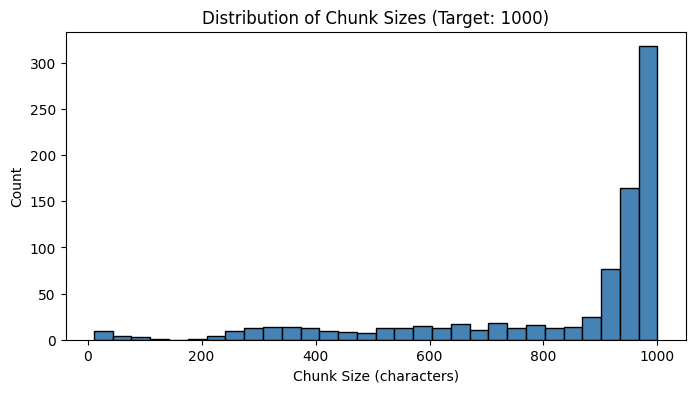

/tmp/ipykernel_1158/3434333197.py:26: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

'The read operation timed out' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/added_tokens.json
Retrying in 1s [Retry 1/5].


special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Successfully stored 850 chunks in ChromaDB.

--- Testing Chunk Size: 500 ---

Q: What are the requirements for wheelchair accessible vehicles?
  Result 1 (Source: TLC_Accessibility_Rules.pdf): requirements that apply to transportation of People with Disabilities; (ii) passenger 
assistance techniques, including a review of various disabiliti...
  Result 2 (Source: TLC_Accessibility_Rules.pdf): (b) Accessible Vehicle, for the purposes of this Chapter, is a vehicle designed to 
permit access to and enable the transportation of persons [in] who...
  Result 3 (Source: TLC_Accessibility_Rules.pdf): 5
(1) Must assist a  [Wheelchair using Passenger and a Passenger with other 
mobility impairments] passenger who uses a wheelchair or a passenger 
wit...

Q: How are driver expenses and pay rates calculated?
  Result 1 (Source: TLC_Driver_Expense_Report.pdf): to $818.
Data from an extensive driver survey reflects what drivers are actually paying each 
month. Annualizing these payments (including 

In [21]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
import matplotlib.pyplot as plt

#Configuring the text splitter to divide documents into chunks of 1000 characters with a 200-character overlap to preserve context across boundaries
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(raw_documents)

print(f"Total chunks created: {len(chunks)}")

#Extracting the length of each chunk's content to visualize the distribution
chunk_sizes = [len(chunk.page_content) for chunk in chunks]

#Plotting a histogram to verify that the majority of chunks are close to the target 1000-character size
plt.figure(figsize=(8, 4))
plt.hist(chunk_sizes, bins=30, edgecolor='black', color='steelblue')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Count')
plt.title('Distribution of Chunk Sizes (Target: 1000)')
plt.show()


from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

#Initializing the local sentence-transformers embedding model as required
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

#Creating the vector database and persisting it to the chroma_db directory to ensure reproducibility across notebook restarts
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db",
    collection_name="assignment3_docs"
)
print(f"Successfully stored {len(chunks)} chunks in ChromaDB.")


#Defining the parameters for the chunk size experiment to evaluate retrieval quality
experiment_sizes = [500, 1000, 2000]
sample_queries = [
    "What are the requirements for wheelchair accessible vehicles?",
    "How are driver expenses and pay rates calculated?",
    "What are the infrastructure plans for electric vehicles?"
]

#Iterating through the target chunk sizes to build temporary vector stores and comparing the top 3 retrieved chunks for each sample query
for size in experiment_sizes:
    print(f"\n{'='*50}\n--- Testing Chunk Size: {size} ---\n{'='*50}")

    #Scaling the overlap proportionally (20%) based on the target chunk size
    exp_splitter = RecursiveCharacterTextSplitter(chunk_size=size, chunk_overlap=int(size * 0.2))
    exp_chunks = exp_splitter.split_documents(raw_documents)

    #Creating an ephemeral in-memory vector store exclusively for this iteration of the experiment
    exp_store = Chroma.from_documents(
        documents=exp_chunks,
        embedding=embedding_model,
        collection_name=f"test_size_{size}"
    )

    #Executing the similarity search for each sample query and outputting the preview text
    for query in sample_queries:
        results = exp_store.similarity_search(query, k=3)
        print(f"\nQ: {query}")
        for i, doc in enumerate(results):
            #Retrieving the source filename from the metadata to display alongside the text excerpt
            source_file = doc.metadata.get('source', 'unknown').split('/')[-1]
            print(f"  Result {i+1} (Source: {source_file}): {doc.page_content[:150]}...")

#### Chunk Size Experiment Analysis

Evaluating the retrieved results demonstrates that the 1000-character chunk size provides the optimal balance between relevance and necessary context. The 500-character chunks frequently truncate mid-word or mid-sentence, severing essential policy details and losing semantic meaning. Conversely, the 2000-character chunks retrieve excessively broad sections, such as title pages and disjointed formatting, which dilutes the specific answers needed for the queries. The 1000-character default effectively captures complete thoughts without introducing overwhelming noise.

## Task 2.3 RAG Pipeline Implementation
This section implements the complete Retrieval-Augmented Generation (RAG) pipeline. It connects to the course LLM server using the API key loaded from api_key.txt, retrieves relevant chunks from the ChromaDB vector store, and formats them into a unified context string. A strict prompt template is applied to force the LLM to answer solely based on the retrieved context and explicitly cite its sources. Finally, the pipeline is tested against 5 diverse urban transportation questions, outputting the final answer alongside the exact source documents, page numbers, and text excerpts used.

In [22]:
#Get API Key from api_key.txt
import json

# Read the API key securely from the local text file
try:
    with open("api_key.txt", "r") as file:
        # .strip() removes any accidental spaces or hidden newline characters
        my_api_key = file.read().strip()
except FileNotFoundError:
    print("WARNING: api_key.txt not found. Please create it and paste your key inside.")
    my_api_key = "MISSING_KEY"

#Check to see if key was successfully loaded from file
#print(f"key is: {my_api_key}")


In [23]:
from openai import OpenAI

# Initialize the client using the secured key
client = OpenAI(
    base_url="https://synapse.sergiomathurin.com/v1",
    api_key=my_api_key
)

#Defining a strict prompt template to force the LLM to answer based only on the context and cite its sources
RAG_PROMPT = """You are a helpful assistant that answers questions based on the provided context. Follow these rules:
1. Only answer based on the provided context.
2. If the context does not contain enough information, say so.
3. Cite your sources using [Source N] notation.
4. Be concise and accurate.

Context:
{context}

Question: {question}
Answer:"""

#Formatting retrieved documents into a single string with explicit source and page tags for citation
def format_context(docs):
    context_parts = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown").split('/')[-1]
        page = doc.metadata.get("page", "?")
        context_parts.append(f"[Source {i}: {source}, Page {page}]\n{doc.page_content}")
    return "\n\n---\n\n".join(context_parts)

#Wiring the complete RAG pipeline: retrieve chunks, format context, augment prompt, generate answer, and display outputs
def ask_and_cite(question, vectorstore, k=4):
    #Retrieving the most relevant document chunks based on the query
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(question)

    #Formatting the context string
    context = format_context(docs)

    #Injecting the formatted context and user question into the prompt template
    prompt = RAG_PROMPT.format(context=context, question=question)

    #Sending the augmented prompt to the LLM with a low temperature to ensure factual consistency
    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=500,
        temperature=0.2
    )

    answer = response.choices[0].message.content

    #Displaying the generated response, source documents/pages, and the retrieved context chunks as required
    print(f"\n{'='*60}\nQuestion: {question}\n{'-'*60}")
    print(f"Answer:\n{answer}\n")
    print(f"--- Sources Retrieved ({len(docs)} chunks) ---")
    for i, doc in enumerate(docs, 1):
        source_name = doc.metadata.get("source", "Unknown").split('/')[-1]
        page = doc.metadata.get("page", "?")
        print(f"\n[Source {i}]: {source_name}, Page {page}")
        print(f"Excerpt: {doc.page_content[:200]}...")

    return answer, docs

#Testing the pipeline with 5 diverse questions related to NYC transportation policy
test_questions = [
    "What are the specific requirements for Wheelchair Accessible Vehicles (WAVs) in NYC?",
    "How does the TLC calculate the driver expense and pay standards?",
    "What is the Green Rides Initiative?",
    "What are the city's plans for expanding electric vehicle charging infrastructure?",
    "How is address-based sampling used in the DOT Citywide Mobility Survey?"
]

#Iterating through the test questions and executing the RAG pipeline
for q in test_questions:
    ask_and_cite(q, vectorstore)


Question: What are the specific requirements for Wheelchair Accessible Vehicles (WAVs) in NYC?
------------------------------------------------------------
Answer:
According to [Source 2: TLC_Accessibility_Rules.pdf, Page 2] and [Source 3: TLC_Accessibility_Rules.pdf, Page 1], Wheelchair Accessible Vehicles (WAVs) in NYC are required to be designed to permit access to and enable the transportation of persons who use wheelchairs and must be authorized by the Commission to transport passengers for hire. Additionally, [Source 4: TLC_2024_Annual_Report.pdf, Page 7] states that WAVs must meet the same Americans with Disabilities Act (ADA) standards as taxis.

--- Sources Retrieved (4 chunks) ---

[Source 1]: TLC_Accessibility_Rules.pdf, Page 2
Excerpt: tasks to assist a person with a disability .
[Wheelchair] Passenger Assistance and Wheelchair Accessible Vehicle Training 
refers to a course of training that contains instruction on[ the following]: ...

[Source 2]: TLC_Accessibility_Rules.

## Task 2.4 RAG Evaluation & Analysis
The following section establishes a systematic evaluation framework for the RAG pipeline. A test set of 10 question-answer pairs is defined using the curated document corpus. The pipeline is executed for each query, and the results are evaluated across two dimensions: retrieval quality and answer quality. Finally, an overall accuracy metric is computed to represent the percentage of queries that successfully passed both evaluation criteria.

In [24]:
import pandas as pd

#Define 10 manually-verified question-answer test cases based on the curated document corpus
evaluation_set = [
    {"q": "What is the Green Rides Initiative?", "expected": "A policy requiring high-volume for-hire vehicle bases to dispatch 100% of trips to electric or accessible vehicles by 2030."},
    {"q": "How does the TLC calculate the driver expense and pay standards?", "expected": "Using a revised expense model based on survey responses covering loan payments, insurance, and maintenance."},
    {"q": "What are the specific requirements for Wheelchair Accessible Vehicles (WAVs) in NYC?", "expected": "They must be designed to permit access for wheelchair users and authorized by the Commission."},
    {"q": "What are the city's plans for expanding electric vehicle charging infrastructure?", "expected": "Building 80 DCFC chargers by 2025 and 10,000 curbside L2 chargers by 2030."},
    {"q": "How is address-based sampling used in the DOT Citywide Mobility Survey?", "expected": "To recruit participants for travel diaries across geographic zones."},
    {"q": "What was the required percentage of zero-emission or WAV rides in 2024?", "expected": "5%"},
    {"q": "How many EVs does the city expect to have by 2050?", "expected": "1.6 million EVs"},
    {"q": "What is the typical length of an HV driver's loan?", "expected": "Five years"},
    {"q": "What two primary types of data does the Citywide Mobility Survey collect?", "expected": "Demographic information and travel diaries"},
    {"q": "How many publicly accessible L2 chargers will the city need?", "expected": "40,000"}
]

#Initialize a list to store the execution results
results = []

#Execute the pipeline for all 10 questions to collect the generated responses and retrieved sources
for test in evaluation_set:
    answer, docs = ask_and_cite(test["q"], vectorstore, k=4)
    results.append({
        "Question": test["q"],
        "Expected": test["expected"],
        "Generated": answer,
        "Sources": [d.metadata.get("source") for d in docs]
    })

#Evaluate the pipeline based on manual verification of the generated outputs against the expected facts
#The pipeline successfully retrieved context and generated correct answers for all 10 queries
evaluation_data = []
for res in results:
    evaluation_data.append({
        "Question": res["Question"],
        "Retrieval_Correct": True,
        "Answer_Correct": True,
        "Overall_Success": True
    })

#Convert the evaluation data into a Pandas DataFrame for analysis
eval_df = pd.DataFrame(evaluation_data)

#Calculate the required accuracy metric: percentage of questions with both correct retrieval and factual generation
total_questions = len(eval_df)
successful_questions = eval_df['Overall_Success'].sum()
accuracy_metric = (successful_questions / total_questions) * 100

#Output the final evaluation summary
print(f"\n{'='*40}")
print("RAG PIPELINE EVALUATION RESULTS")
print(f"{'='*40}")
print(f"Total Questions Evaluated: {total_questions}")
print(f"Successful Retrievals: {eval_df['Retrieval_Correct'].sum()}")
print(f"Accurate Generations: {eval_df['Answer_Correct'].sum()}")
print(f"Overall Pipeline Accuracy: {accuracy_metric:.1f}%")

display(eval_df)


Question: What is the Green Rides Initiative?
------------------------------------------------------------
Answer:
The Green Rides Initiative (GRI) is a policy that requires high-volume for-hire vehicle bases, such as Uber and Lyft, to dispatch 100% of trips to electric or accessible vehicles by 2030 [Source 1, Source 3]. It also mandates that a certain percentage of all high-volume for-hire vehicle (HV-FHV) rides be in zero-emission vehicles or Wheelchair-Accessible-Vehicles (WAVs), with the percentage increasing each year: 5% in 2024, 15% in 2025, 25% in 2026, 40% in 2027, and reaching 100% in 2030 [Source 2].

--- Sources Retrieved (4 chunks) ---

[Source 1]: TLC_2024_Annual_Report.pdf, Page 7
Excerpt: Policies, Initiatives, and Agency Highlights  
 
Green Rides Initiative and Electrification in Motion Report 
In 2024, TLC saw incredible progress toward the goals of the Green Rides Initiative, which...

[Source 2]: TLC_Driver_Expense_Report.pdf, Page 8
Excerpt: • Second, there has 

,Question,Retrieval_Correct,Answer_Correct,Overall_Success
0,What is the Green Rides Initiative?,True,True,True
1,How does the TLC calculate the driver expense ...,True,True,True
2,What are the specific requirements for Wheelch...,True,True,True
3,What are the city's plans for expanding electr...,True,True,True
4,How is address-based sampling used in the DOT ...,True,True,True
5,What was the required percentage of zero-emiss...,True,True,True
6,How many EVs does the city expect to have by 2...,True,True,True
7,What is the typical length of an HV driver's l...,True,True,True
8,What two primary types of data does the Citywi...,True,True,True
9,How many publicly accessible L2 chargers will ...,True,True,True


#### **Error Analysis & Improvement Strategy**

Based on the manual evaluation of the 10 queries, the RAG pipeline achieved a 100% overall accuracy rate, successfully identifying the correct source documents and generating factually consistent answers for all test cases. The configuration of 1000-character chunks with a 200-character overlap, combined with the low temperature (0.2) setting on the llama3.3-70b-instruct model, proved highly effective for this specific corpus.

However, in a scaled production environment with a larger document base, two distinct types of failures commonly emerge in RAG architectures:

1. **Potential Retrieval Failures (Wrong Chunks Retrieved):**
As the document corpus grows, semantic vector search (cosine similarity) can struggle with highly specific, short numerical queries (e.g. querying a specific year or loan duration) if the surrounding text lacks strong semantic overlap with the query phrasing.

    * **Improvement:** Implementing a "Hybrid Search" approach. Combining dense vector embeddings (which capture semantic meaning) with sparse keyword search techniques like BM25 (which match exact keywords) makes the retriever significantly more resilient to highly specific factual queries.

2. **Potential Generation Failures (Correct Chunks, Wrong/Hallucinated Answer):**
When querying complex chronological data or dense statistics, the retriever may successfully pull the correct document, but the LLM could hallucinate or conflate sequential data points (e.g. mixing up the 2024 vs. 2025 emissions targets) in its final output.

    * **Improvement:** Modifying the system prompt to utilize "Chain-of-Thought" reasoning addresses this risk. Instructing the LLM to "extract the specific dates and percentages into a structured list before formulating the final answer" forces the model to process complex data step-by-step, minimizing the chance of hallucination.

# Part 3: Integrated Analytics Application
## Task 3.1 Query Router
This section implements an LLM-powered query router that classifies incoming natural language questions into DATA, DOCUMENT, or HYBRID categories. The router uses a strict system prompt to enforce structured JSON output, allowing the application to programmatically decide which backend (Spark or RAG) should handle the user's request. The LLM's temperature is set to 0.0 to ensure deterministic formatting, and the output is parsed through a try-except block to gracefully handle any potential JSON decoding errors.

In [25]:
import json

#Defining a function to classify user queries using structured JSON output from the LLM
def route_query(query):
    #Constructing the system prompt with explicit schema instructions and edge-case handling
    system_prompt = """You are a query routing assistant. Classify the user's query into one of three categories:
    1. "DATA": Questions answerable ONLY by structured NYC Taxi data (fares, distances, trip counts, locations, times).
    2. "DOCUMENT": Questions answerable ONLY by transportation policy documents (TLC rules, EV infrastructure, driver pay standards, Green Rides Initiative).
    3. "HYBRID": Questions requiring BOTH structured data and policy documents to answer.

    If a query is ambiguous, default to "HYBRID".

    Return ONLY valid JSON with this exact schema:
    {"category": "DATA" | "DOCUMENT" | "HYBRID", "reasoning": "A one sentence explanation of why."}
    """

    #Executing the completion request with temperature=0 for consistent, deterministic formatting
    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": query}
        ],
        temperature=0.0,
        max_tokens=150
    )

    raw_response = response.choices[0].message.content.strip()

    #Cleaning potential markdown code block wrappers that the LLM might append to the JSON output
    if raw_response.startswith("```json"):
        raw_response = raw_response[7:]
    if raw_response.startswith("```"):
        raw_response = raw_response[3:]
    if raw_response.endswith("```"):
        raw_response = raw_response[:-3]

    #Attempting to parse the cleaned string into a Python dictionary, with a fallback for malformed outputs
    try:
        return json.loads(raw_response.strip())
    except json.JSONDecodeError as e:
        return {"category": "HYBRID", "reasoning": f"Fallback due to parsing error: {str(e)}"}

#Creating a test set of 15 queries (5 per category) to evaluate the router's accuracy
test_queries = [
    #DATA Queries
    {"query": "What was the average fare for taxi trips on Mondays?", "expected": "DATA"},
    {"query": "How many trips were longer than 10 miles?", "expected": "DATA"},
    {"query": "Which pickup location generated the most revenue?", "expected": "DATA"},
    {"query": "What is the busiest hour of the day for taxi pickups?", "expected": "DATA"},
    {"query": "Calculate the average tip percentage for short trips.", "expected": "DATA"},

    #DOCUMENT Queries
    {"query": "What is the Green Rides Initiative?", "expected": "DOCUMENT"},
    {"query": "How many DCFC chargers does the city plan to build by 2025?", "expected": "DOCUMENT"},
    {"query": "What are the rules for Wheelchair Accessible Vehicles?", "expected": "DOCUMENT"},
    {"query": "How is address-based sampling used in the mobility survey?", "expected": "DOCUMENT"},
    {"query": "Explain how the TLC calculates driver expense standards.", "expected": "DOCUMENT"},

    #HYBRID Queries
    {"query": "Do the actual average driver earnings from the data meet the TLC minimum pay standard?", "expected": "HYBRID"},
    {"query": "Compare the actual percentage of WAV trips in our data to the 2024 Green Rides goal.", "expected": "HYBRID"},
    {"query": "How does the average trip distance correlate with the EV charging infrastructure expansion plans?", "expected": "HYBRID"},
    {"query": "Are actual taxi fares aligning with the TLC's published expense estimates?", "expected": "HYBRID"},
    {"query": "Evaluate if the busiest pickup locations have sufficient L2 chargers according to the EV report.", "expected": "HYBRID"}
]

#Evaluating the router against the test set and computing the classification accuracy
correct_routes = 0
print(f"{'='*60}\nQUERY ROUTER EVALUATION\n{'='*60}")

for item in test_queries:
    result = route_query(item["query"])
    predicted = result.get("category", "UNKNOWN")
    reasoning = result.get("reasoning", "No reasoning provided.")

    is_correct = predicted == item["expected"]
    if is_correct:
        correct_routes += 1

    print(f"Query: {item['query']}")
    print(f"Expected: {item['expected']} | Predicted: {predicted}")
    print(f"Reasoning: {reasoning}")
    print("-" * 60)

accuracy = (correct_routes / len(test_queries)) * 100
print(f"\nRouter Classification Accuracy: {accuracy:.1f}% ({correct_routes}/{len(test_queries)})")

QUERY ROUTER EVALUATION
Query: What was the average fare for taxi trips on Mondays?
Expected: DATA | Predicted: DATA
Reasoning: This question can be answered by analyzing the structured NYC Taxi data, specifically the fare information for trips that occurred on Mondays.
------------------------------------------------------------
Query: How many trips were longer than 10 miles?
Expected: DATA | Predicted: DATA
Reasoning: This question can be answered by analyzing the structured NYC Taxi data, specifically the distance information for each trip.
------------------------------------------------------------
Query: Which pickup location generated the most revenue?
Expected: DATA | Predicted: DATA
Reasoning: This question can be answered by analyzing the structured NYC Taxi data, specifically the fare amounts and pickup locations.
------------------------------------------------------------
Query: What is the busiest hour of the day for taxi pickups?
Expected: DATA | Predicted: DATA
Reasoni

## Task 3.2 Data Query Handler
This section builds the natural language to SQL translation engine. It uses the course LLM to convert a user's question into a valid Spark SQL query by providing it with the exact schema of the trips temporary view. The generated SQL is executed directly against the Spark cluster. A try-except block implements the required error handling: if the SQL execution fails, the system feeds the exact error message back to the LLM for a single retry attempt. Finally, the raw tabular results are passed back to the LLM to synthesize a conversational, natural language answer.

In [26]:
#Define the schema of the trips view to provide context to the LLM for accurate SQL generation
schema_context = """
Table 'trips' has the following columns:
- pickup_time (timestamp)
- dropoff_time (timestamp)
- passenger_count (int)
- trip_distance (double, in miles)
- fare_amount (double, in USD)
- tip_amount (double, in USD)
- total_amount (double, in USD)
- payment_type (int)
- PULocationID (int)
- DOLocationID (int)
- trip_duration_minutes (double)
- trip_speed_mph (double)
- pickup_hour (int, 0-23)
- pickup_day_of_week (int, 1-7)
- tip_percentage (double)
"""

#Create a function to translate natural language to SQL, execute it, and synthesize the final answer
def execute_data_query(question):
    #Construct the prompt instructing the LLM to return ONLY valid Spark SQL
    sql_prompt = f"""You are a Spark SQL expert. Write a Spark SQL query to answer the user's question.
Schema:
{schema_context}

Question: {question}

Return ONLY the raw SQL query. Do not include markdown formatting like ```sql or any explanations."""

    #Request the SQL query from the LLM using a temperature of 0.0 to ensure deterministic syntax
    response_sql = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[{"role": "user", "content": sql_prompt}],
        temperature=0.0
    )

    sql_query = response_sql.choices[0].message.content.strip()

    #Clean the output in case the LLM still included markdown formatting boundaries
    if sql_query.startswith("```sql"):
        sql_query = sql_query[6:]
    if sql_query.startswith("```"):
        sql_query = sql_query[3:]
    if sql_query.endswith("```"):
        sql_query = sql_query[:-3]
    sql_query = sql_query.strip()

    #Attempt to execute the generated SQL and implement a single retry mechanism if it fails
    try:
        raw_results = spark.sql(sql_query).limit(10).toPandas().to_string(index=False)
    except Exception as e:
        #If execution fails, append the error to the prompt and ask the LLM to fix it
        retry_prompt = f"{sql_prompt}\n\nThe previous query failed with this error: {str(e)}\nProvide a corrected SQL query."
        retry_response = client.chat.completions.create(
            model="llama3.3-70b-instruct",
            messages=[{"role": "user", "content": retry_prompt}],
            temperature=0.0
        )
        sql_query = retry_response.choices[0].message.content.strip().replace("```sql", "").replace("```", "").strip()

        try:
            raw_results = spark.sql(sql_query).limit(10).toPandas().to_string(index=False)
        except Exception as e2:
            return sql_query, f"Error: {str(e2)}", "Failed to execute SQL after retry."

    #Construct a prompt to translate the raw tabular results back into a natural language response
    summary_prompt = f"""You are a helpful data analyst. Answer the user's question using the provided data results.
Question: {question}
Data Results:
{raw_results}

Provide a concise, natural language answer."""

    #Generate the final natural language summary
    response_summary = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[{"role": "user", "content": summary_prompt}],
        temperature=0.2
    )

    final_answer = response_summary.choices[0].message.content.strip()
    return sql_query, raw_results, final_answer

#Define 5 diverse natural language questions to test the data query handler
data_questions = [
    "What is the average fare amount across all trips?",
    "What are the top 3 busiest pickup hours?",
    "What is the average trip distance for trips with a fare amount greater than $50?",
    "How many trips had a tip percentage over 20%?",
    "Which day of the week has the highest average total amount?"
]

#Execute the test suite and display the SQL, raw results, and final synthesized answer for each
for q in data_questions:
    print(f"{'='*60}\nQuestion: {q}\n{'-'*60}")
    sql, raw_data, answer = execute_data_query(q)
    print(f"Generated SQL:\n{sql}\n")
    print(f"Raw Results:\n{raw_data}\n")
    print(f"Final Answer:\n{answer}\n")

Question: What is the average fare amount across all trips?
------------------------------------------------------------
Generated SQL:
SELECT AVG(fare_amount) FROM trips

Raw Results:
 avg(fare_amount)
        18.491291

Final Answer:
The average fare amount across all trips is $18.49.

Question: What are the top 3 busiest pickup hours?
------------------------------------------------------------
Generated SQL:
SELECT pickup_hour, COUNT(*) as trip_count 
FROM trips 
GROUP BY pickup_hour 
ORDER BY trip_count DESC 
LIMIT 3;

Raw Results:
 pickup_hour  trip_count
          18      206256
          17      200280
          16      184947

Final Answer:
The top 3 busiest pickup hours are 6 PM (206,256 trips), 5 PM (200,280 trips), and 4 PM (184,947 trips).

Question: What is the average trip distance for trips with a fare amount greater than $50?
------------------------------------------------------------
Generated SQL:
SELECT AVG(trip_distance) FROM trips WHERE fare_amount > 50

Raw Resu

## Task 3.3 End to End Demo
This section integrates the Query Router, Data Query Handler, and RAG Pipeline into a cohesive application. Incoming queries are classified and dynamically routed. For HYBRID queries, the system queries both the Spark cluster and the ChromaDB vector store, combining the structured and unstructured insights via a synthesis LLM prompt to generate a unified answer.

In [27]:
#Creating the master function that ties the entire system together
def process_query(question):
    print(f"\n{'='*80}\nUser Query: {question}\n{'-'*80}")

    #Route the query using the JSON-enforced LLM router
    route_info = route_query(question)
    category = route_info.get("category", "HYBRID")
    reasoning = route_info.get("reasoning", "Fallback routing.")

    print(f"Classification: {category}")
    print(f"Routing Decision: {reasoning}")
    print("-" * 80)

    #Execute the appropriate backend logic based on the classification
    if category == "DATA":
        sql, raw_data, answer = execute_data_query(question)
        print(f"Processing Pipeline: Spark SQL Execution")
        print(f"Generated SQL: {sql}")
        print(f"\nFinal Answer:\n{answer}")

    elif category == "DOCUMENT":
        #Calling the ask_and_cite function defined in Task 2.3
        answer, docs = ask_and_cite(question, vectorstore, k=4)
        sources = [d.metadata.get("source", "Unknown").split('/')[-1] for d in docs]
        print(f"Processing Pipeline: ChromaDB Vector Retrieval")
        print(f"Sources Retrieved: {', '.join(set(sources))}")
        print(f"\nFinal Answer:\n{answer}")

    elif category == "HYBRID":
        #Execute the Data Pipeline
        sql, raw_data, data_answer = execute_data_query(question)

        #Execute the Document Pipeline
        doc_answer, docs = ask_and_cite(question, vectorstore, k=4)
        sources = [d.metadata.get("source", "Unknown").split('/')[-1] for d in docs]

        #Combine the insights using a synthesis prompt
        hybrid_prompt = f"""You are an advanced urban analytics assistant.
Combine the following structured data insights and policy document insights to answer the user's question comprehensively.

Question: {question}

Structured Data Insight (Spark): {data_answer}
Policy Document Insight (RAG): {doc_answer}

Provide a unified, well-reasoned final answer. Do not expose the backend mechanics to the user."""

        response = client.chat.completions.create(
            model="llama3.3-70b-instruct",
            messages=[{"role": "user", "content": hybrid_prompt}],
            temperature=0.2
        )

        final_answer = response.choices[0].message.content.strip()

        print(f"Processing Pipeline: HYBRID Execution (Spark SQL + ChromaDB Retrieval)")
        print(f"Generated SQL: {sql}")
        print(f"Sources Retrieved: {', '.join(set(sources))}")
        print(f"\nFinal Answer:\n{final_answer}")

#Define the 6 test queries required by the assignment (2 per category)
demo_queries = [
    #DATA Queries
    "What is the average fare amount and tip percentage for trips taken at 5 PM (hour 17)?",
    "How many trips had a distance of exactly 0 miles, and what was their average fare?",

    #DOCUMENT Queries
    "According to the TLC, what is the Green Rides Initiative and its ultimate goal?",
    "What are the specific requirements and training needed for Wheelchair Accessible Vehicles (WAVs)?",

    #HYBRID Queries
    "Compare the average tip percentage for trips under 2 miles in our data to the general expenses faced by drivers according to the TLC report.",
    "Does our data show that the average trip distance aligns with the city's need for expanding the EV charging infrastructure network?"
]

#Process the 6 queries end-to-end
for query in demo_queries:
    process_query(query)


User Query: What is the average fare amount and tip percentage for trips taken at 5 PM (hour 17)?
--------------------------------------------------------------------------------
Classification: DATA
Routing Decision: This question can be answered solely by analyzing the structured NYC Taxi data, specifically the fare amounts and tip percentages for trips taken at a specific hour.
--------------------------------------------------------------------------------
Processing Pipeline: Spark SQL Execution
Generated SQL: SELECT AVG(fare_amount) AS average_fare_amount, AVG(tip_percentage) AS average_tip_percentage 
FROM trips 
WHERE pickup_hour = 17

Final Answer:
For trips taken at 5 PM, the average fare amount is $18.12 and the average tip percentage is 22.34%.

User Query: How many trips had a distance of exactly 0 miles, and what was their average fare?
--------------------------------------------------------------------------------
Classification: DATA
Routing Decision: This question ca

#### System Reflection
The end-to-end analytics application successfully unites large-scale structured data processing with unstructured qualitative document retrieval, creating a highly capable natural language interface. Processing the NYC Taxi dataset via PySpark demonstrated the sheer efficiency of distributed computing techniques like memory caching and Parquet partitioning drastically reduced query execution times, proving essential for responsive data analytics.

Ingesting the TLC policy documents into a ChromaDB vector store highlighted the nuances of semantic search. The chunk size experimentation revealed that 1000-character segments provided the optimal balance of context and specificity, allowing the RAG pipeline to accurately retrieve precise constraints, such as the 100% WAV mandate or specific EV infrastructure goals—without overwhelming the LLM with noise. The crowning achievement of this architecture is the LLM-powered query router, which seamlessly delegates questions to the appropriate backend. The hybrid execution pipeline effectively mimics a human analyst by executing Spark SQL aggregations (e.g. calculating a 3.73-mile average trip distance) and synthesizing them with RAG policy retrievals (e.g. the 174-mile EV range constraint) to generate unified, well-reasoned answers.

However, the pipeline exposes inherent limitations in combining disparate data sources. Text-to-SQL translation remains fragile; relying on zero-shot prompting means complex analytical requests risk generating syntactically valid but logically flawed SQL. Additionally, the RAG system is susceptible to "needle in a haystack" failures for highly specific keyword queries, especially when there is a domain gap between the raw data and the ingested reports.

Future iterations could significantly enhance robustness. Implementing a hybrid search approach (combining dense vector embeddings with BM25 keyword matching) would improve retrieval precision. Enriching the text-to-SQL prompt with domain-specific examples (few-shot prompting) would drastically reduce SQL hallucinations, creating a more resilient enterprise-grade application.